# SVM支持向量机实验

**实验目标**：
1. 掌握SVM基本原理
2. 实现不同核函数的SVM
3. 学习超参数调优
4. 培养数据分析和可视化能力


In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
os.makedirs('figures', exist_ok=True)
print('环境准备完毕！')

环境准备完毕！


## 运行完整实验

执行下面的单元格将运行完整的SVM实验，包括数据加载、模型训练、超参数调优和报告生成。


In [2]:
# 运行完整实验
# 如果遇到导入错误，请确保所有.py文件在同一目录下
import sys
sys.path.append('.')

# 方法1：直接运行main.py
# %run main.py

# 方法2：逐步运行（推荐，可以看到每一步的输出）
print('开始SVM实验...')
print('请继续运行下面的单元格')

开始SVM实验...
请继续运行下面的单元格


## 第一步：数据加载


SVM支持向量机实验
实验环境准备完毕！


第一部分：数据加载与探索

1. 加载Iris鸢尾花数据集（线性可分）
------------------------------------------------------------
数据集形状：(150, 4)
特征数量：4
样本数量：150
类别数量：3

各类别样本数量：
target_name
Setosa         50
Versicolour    50
Virginica      50
Name: count, dtype: int64

2. 加载乳腺癌数据集（非线性可分）
------------------------------------------------------------
数据集形状：(569, 30)
特征数量：30
样本数量：569
类别数量：2

各类别样本数量：
target_name
benign       357
malignant    212
Name: count, dtype: int64

3. 数据可视化
------------------------------------------------------------


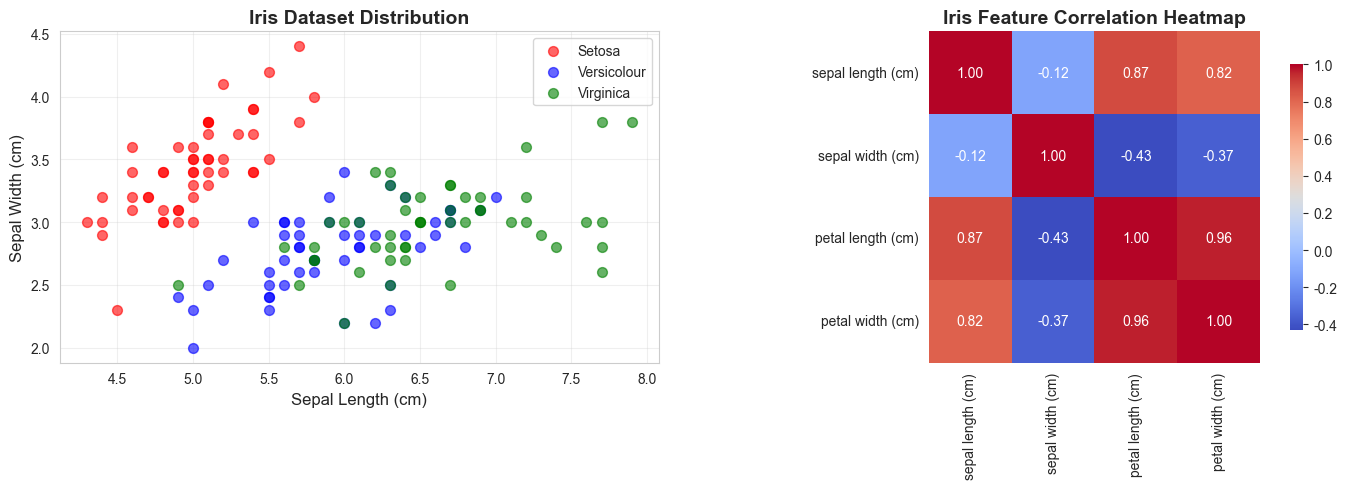

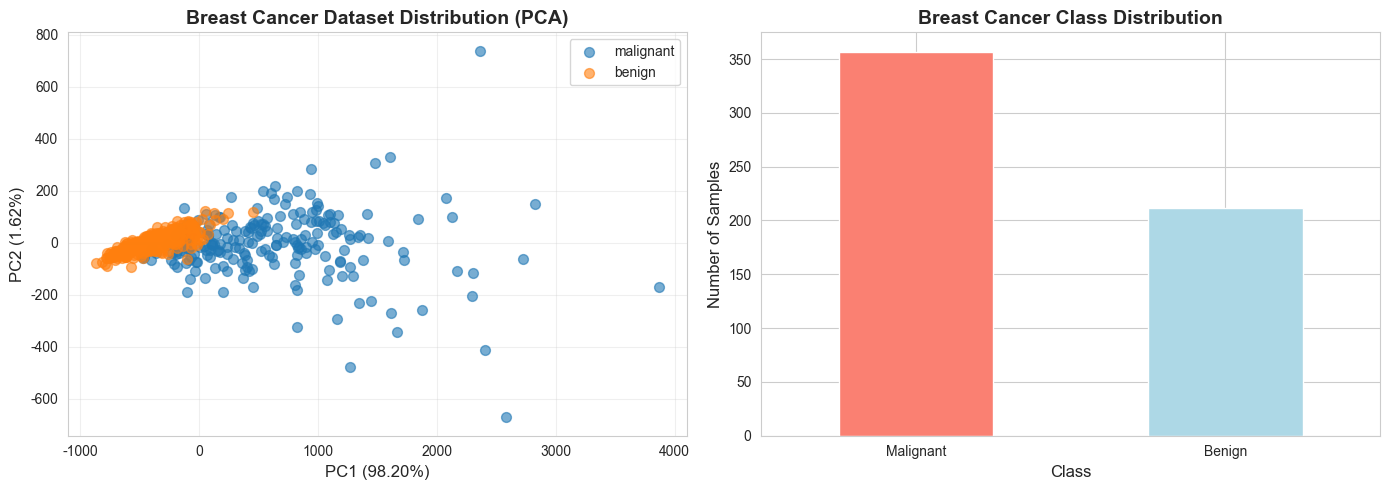

数据可视化完成！

第二部分：数据预处理

1. Iris数据集预处理
------------------------------------------------------------
训练集大小：(105, 4)
测试集大小：(45, 4)
标准化完成！

2. 乳腺癌数据集预处理
------------------------------------------------------------
训练集大小：(398, 30)
测试集大小：(171, 30)
标准化完成！


In [3]:
from svm_experiment_part1 import load_and_explore_data, visualize_data, preprocess_data

# 加载数据
iris, cancer, iris_df, cancer_df = load_and_explore_data()

# 可视化
visualize_data(iris_df, cancer_df)

# 预处理
data = preprocess_data(iris, cancer)
(X_iris_train, X_iris_test, y_iris_train, y_iris_test,
 X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test,
 scaler_iris, scaler_cancer) = data

## 第二步：模型训练



第三部分：Iris数据集 - SVM模型训练

线性核SVM训练中...
------------------------------------------------------------
测试集准确率：0.9111
交叉验证准确率：0.9714 (+/- 0.0233)
支持向量数量：[ 2 10  9]

多项式核SVM训练中...
------------------------------------------------------------
测试集准确率：0.8667
交叉验证准确率：0.8952 (+/- 0.0190)
支持向量数量：[ 3 20 16]

高斯核(RBF)SVM训练中...
------------------------------------------------------------
测试集准确率：0.9333
交叉验证准确率：0.9714 (+/- 0.0233)
支持向量数量：[ 6 18 16]

第四部分：Iris数据集 - 模型性能评估

线性核SVM评估结果：
------------------------------------------------------------

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


混淆矩阵：
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

多项式核SVM评估结果：
----------------------

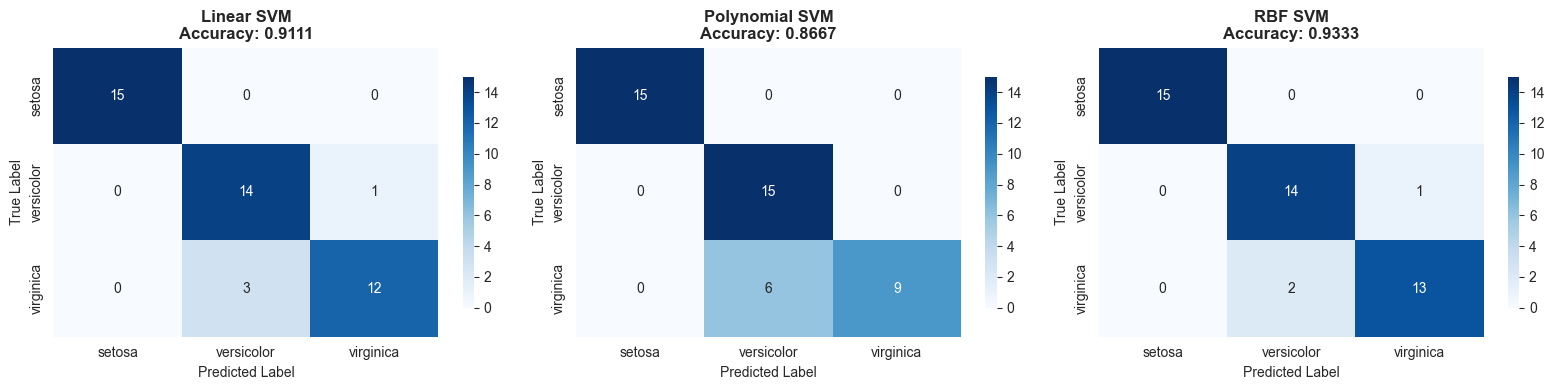

混淆矩阵已保存：figures/03_iris_confusion_matrices.png


In [4]:
from svm_experiment_part2 import (train_svm_models, evaluate_models, 
                                   plot_confusion_matrices, plot_model_comparison)

# 训练Iris数据集
models_iris, results_iris = train_svm_models(
    X_iris_train, y_iris_train, X_iris_test, y_iris_test, 'Iris数据集'
)

# 评估
evaluate_models(models_iris, results_iris, X_iris_test, y_iris_test, 
               'Iris数据集', iris.target_names)

# 混淆矩阵
plot_confusion_matrices(results_iris, y_iris_test, 'iris', iris.target_names)


第三部分：乳腺癌数据集 - SVM模型训练

线性核SVM训练中...
------------------------------------------------------------
测试集准确率：0.9825
交叉验证准确率：0.9673 (+/- 0.0170)
支持向量数量：[14 17]

多项式核SVM训练中...
------------------------------------------------------------
测试集准确率：0.8947
交叉验证准确率：0.8944 (+/- 0.0251)
支持向量数量：[63 62]

高斯核(RBF)SVM训练中...
------------------------------------------------------------
测试集准确率：0.9766
交叉验证准确率：0.9698 (+/- 0.0129)
支持向量数量：[49 42]

第四部分：乳腺癌数据集 - 模型性能评估

线性核SVM评估结果：
------------------------------------------------------------

分类报告：
              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


混淆矩阵：
[[ 62   2]
 [  1 106]]

多项式核SVM评估结果：
------------------------------------------------------------

分类报告：
              precision    recall

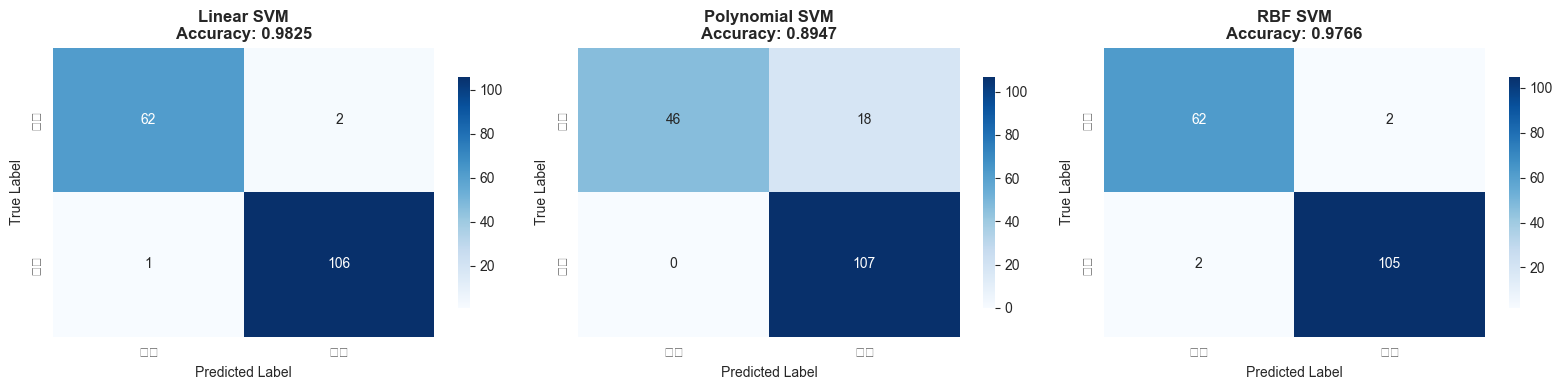

混淆矩阵已保存：figures/03_cancer_confusion_matrices.png

绘制模型性能对比图...


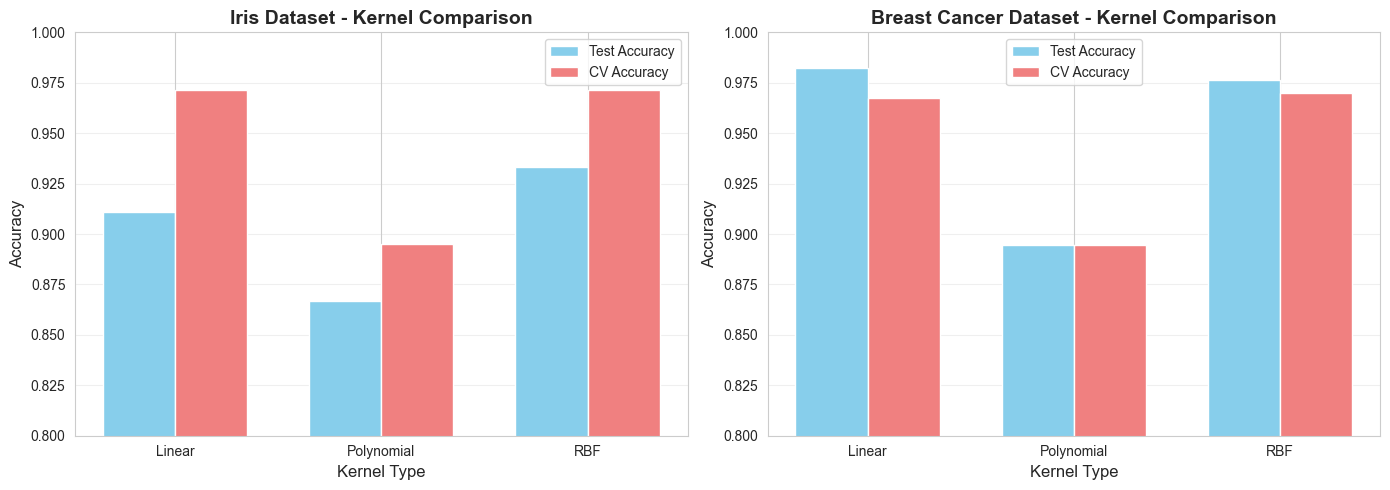

模型性能对比图已保存：figures/04_model_comparison.png


In [5]:
# 训练乳腺癌数据集
models_cancer, results_cancer = train_svm_models(
    X_cancer_train, y_cancer_train, X_cancer_test, y_cancer_test, '乳腺癌数据集'
)

# 评估
evaluate_models(models_cancer, results_cancer, X_cancer_test, y_cancer_test,
               '乳腺癌数据集', ['malignant', 'benign'])

# 混淆矩阵
plot_confusion_matrices(results_cancer, y_cancer_test, 'cancer', ['恶性', '良性'])

# 性能对比
plot_model_comparison(results_iris, results_cancer)

## 第三步：超参数调优



第五部分：Iris数据集 - 超参数调优

参数搜索空间：
C: [0.1, 1, 10, 100]
gamma: [0.001, 0.01, 0.1, 1]
kernel: ['rbf']

开始网格搜索...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

最佳参数：
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

最佳模型交叉验证准确率：0.9810
最佳模型测试集准确率：0.9111

绘制iris超参数调优热力图...


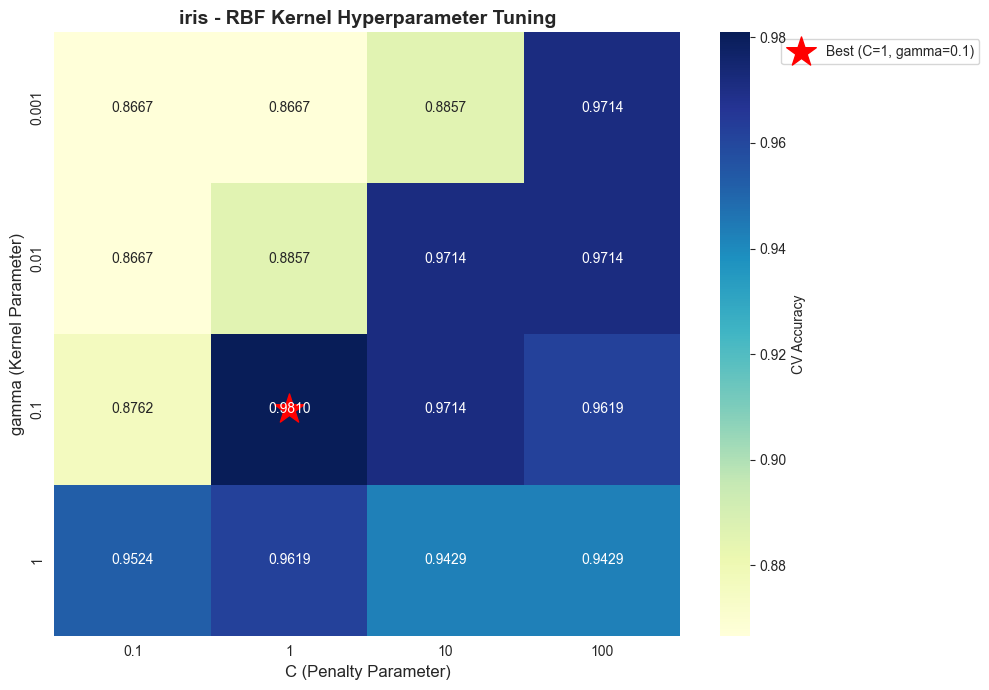

超参数调优热力图已保存：figures/05_iris_hyperparameter_tuning.png

第五部分：乳腺癌数据集 - 超参数调优

参数搜索空间：
C: [0.1, 1, 10, 100]
gamma: [0.001, 0.01, 0.1, 1]
kernel: ['rbf']

开始网格搜索...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

最佳参数：
{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

最佳模型交叉验证准确率：0.9799
最佳模型测试集准确率：0.9708

绘制cancer超参数调优热力图...


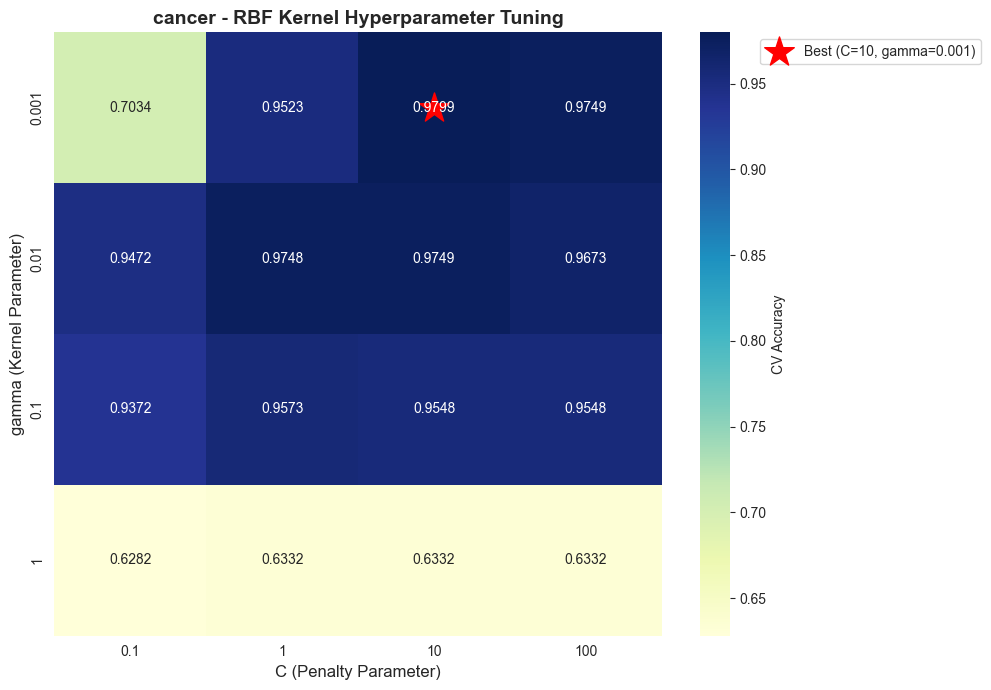

超参数调优热力图已保存：figures/05_cancer_hyperparameter_tuning.png


In [6]:
from svm_experiment_part3 import (hyperparameter_tuning, plot_hyperparameter_heatmap,
                                   compare_before_after_tuning, plot_tuning_improvement)

# Iris数据集调优
tuning_results_iris = hyperparameter_tuning(
    X_iris_train, y_iris_train, X_iris_test, y_iris_test, 'Iris数据集'
)
plot_hyperparameter_heatmap(tuning_results_iris, 'iris')

# 乳腺癌数据集调优
tuning_results_cancer = hyperparameter_tuning(
    X_cancer_train, y_cancer_train, X_cancer_test, y_cancer_test, '乳腺癌数据集'
)
plot_hyperparameter_heatmap(tuning_results_cancer, 'cancer')


Iris数据集 - 调优前后性能对比：
------------------------------------------------------------
调优前准确率：0.9333
调优后准确率：0.9111
性能提升：-2.22%

乳腺癌数据集 - 调优前后性能对比：
------------------------------------------------------------
调优前准确率：0.9766
调优后准确率：0.9708
性能提升：-0.58%

绘制调优前后性能提升图...


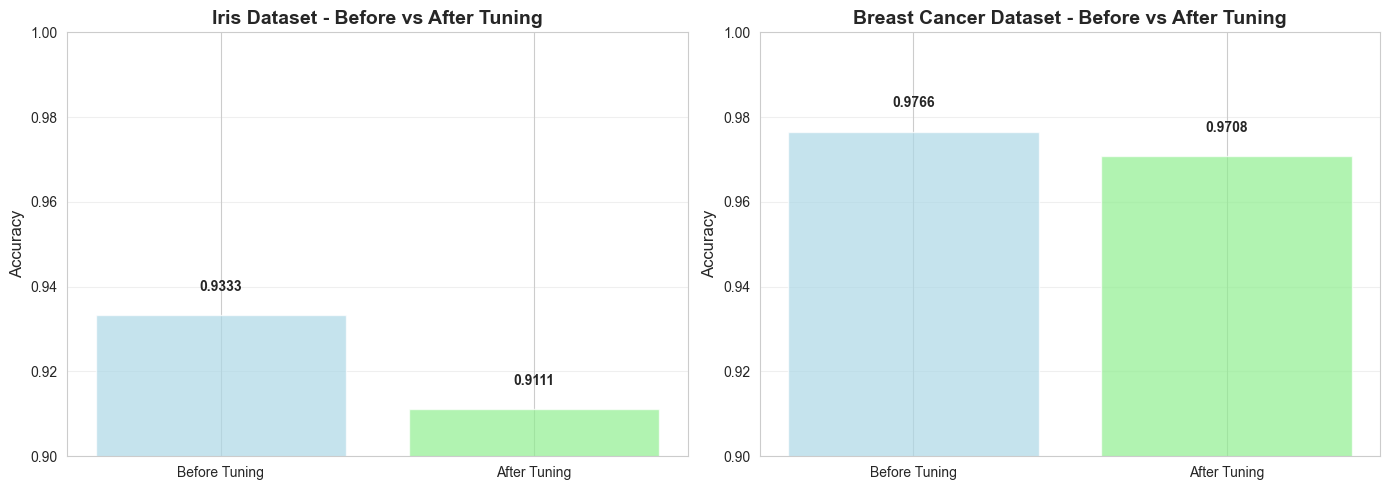

调优前后性能提升图已保存：figures/07_tuning_improvement.png


In [7]:
# 调优前后对比
comparison_iris = compare_before_after_tuning(results_iris, tuning_results_iris, 'Iris数据集')
comparison_cancer = compare_before_after_tuning(results_cancer, tuning_results_cancer, '乳腺癌数据集')
plot_tuning_improvement(comparison_iris, comparison_cancer)

## 第四步：生成Word报告


In [ ]:
from generate_report import generate_word_report

# 生成报告
generate_word_report()
print('\n实验完成！Word报告已生成：SVM实验报告.docx')